# Simulasi Chaos Theory & Butterfly Effect: Atraktor Lorenz

Notebook ini memvisualisasikan **Atraktor Lorenz** dan mensimulasikan konsep **Butterfly Effect** (Sensitivitas Ekstrem terhadap Kondisi Awal) yang ditemukan oleh meteorolog Edward Lorenz pada tahun 1963.

## Persamaan Atraktor Lorenz
Sistem Lorenz didefinisikan oleh tiga persamaan diferensial ordinat non-linear berikut:

$$\frac{dx}{dt} = \sigma (y - x)$$
$$\frac{dy}{dt} = x (\rho - z) - y$$
$$\frac{dz}{dt} = xy - \beta z$$

Di mana parameter standar yang sering digunakan untuk menghasilkan perilaku kaotis (*chaotic behavior*) adalah:
- $\sigma = 10$ (Prandtl number)
- $\rho = 28$ (Rayleigh number)
- $\beta = 8/3$ (Dimensi fisik geometri)

## Demo Butterfly Effect
Kita akan mensimulasikan dua titik awal yang hanya berbeda sebesar **0.0001** pada koordinat awal $x$:
- Kondisi Awal 1: $[1.0, 1.0, 1.0]$
- Kondisi Awal 2: $[1.0001, 1.0, 1.0]$

Kita akan melihat bagaimana kedua lintasan ini awalnya berhimpit, namun lama-kelamaan menyimpang secara ekstrem hingga membentuk pola sayap kupu-kupu yang berbeda.

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from mpl_toolkits.mplot3d import Axes3D  # Register 3D projection if needed
import matplotlib as mpl

# Set premium styling
plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams['figure.figsize'] = (14, 8)
mpl.rcParams['font.size'] = 11
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['axes.titlesize'] = 14


## 1. Definisi Persamaan Lorenz

In [28]:
def lorenz(t, state, sigma=10.0, rho=28.0, beta=8/3):
    """
    Menghitung turunan dx/dt, dy/dt, dz/dt pada titik state(x, y, z)
    """
    x, y, z = state
    dxdt = sigma * (y - x)
    dydt = x * (rho - z) - y
    dzdt = x * y - beta * z
    return [dxdt, dydt, dzdt]


## 2. Simulasi Integrasi Numerik Dua Kondisi Awal

In [33]:
# Parameter Waktu
t_start = 0.0
t_end = 40.0
t_eval = np.linspace(t_start, t_end, 4000)

# Kondisi Awal 1 (Lintasan Biru)
state1 = [1.0, 1.0, 1.0]

# Kondisi Awal 2 dengan selisih sangat tipis (Lintasan Merah-Oranye)
state2 = [1.0001, 1.00001, 1.00001]

# Integrasi Numerik menggunakan metode Runge-Kutta 45 (solve_ivp)
sol1 = solve_ivp(lorenz, [t_start, t_end], state1, t_eval=t_eval, rtol=1e-10, atol=1e-11)
sol2 = solve_ivp(lorenz, [t_start, t_end], state2, t_eval=t_eval, rtol=1e-10, atol=1e-11)

x1, y1, z1 = sol1.y
x2, y2, z2 = sol2.y

print("Integrasi selesai. Jumlah titik data:", len(t_eval))


Integrasi selesai. Jumlah titik data: 4000


## 3. Visualisasi 3D Atraktor Lorenz (Pola Sayap Kupu-Kupu)

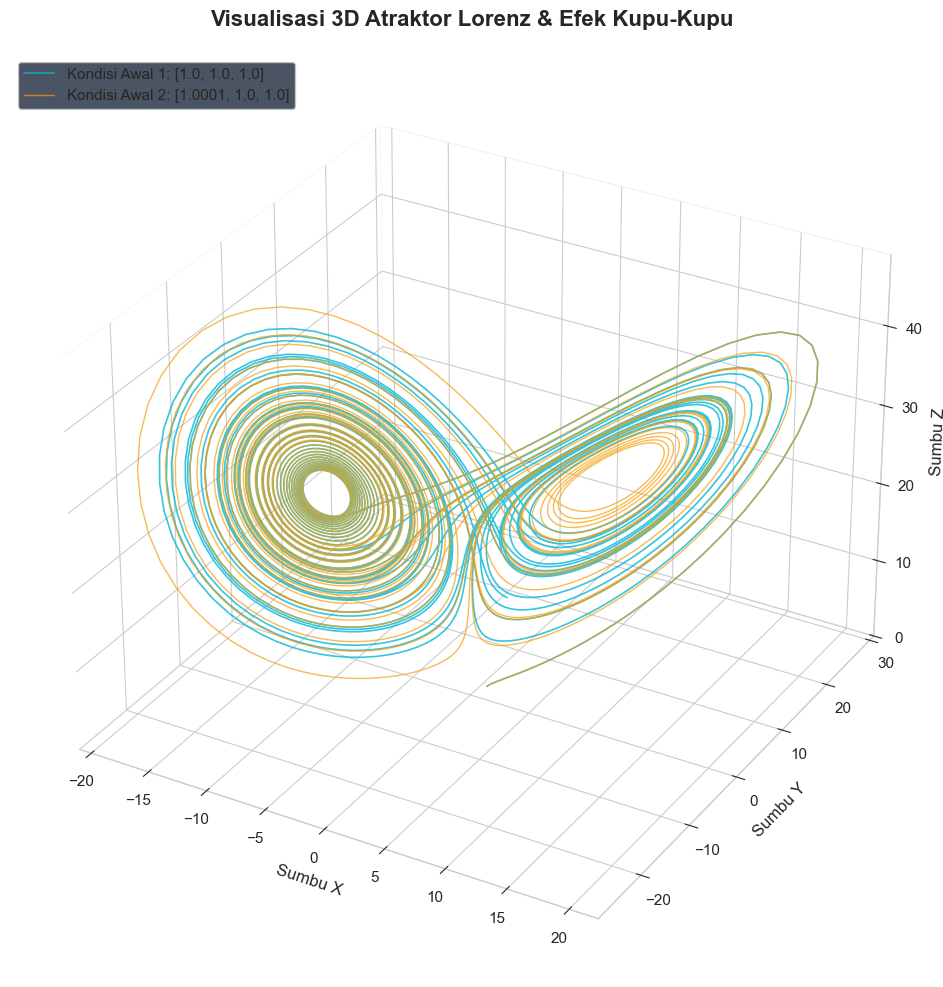

In [34]:
fig = plt.figure(figsize=(16, 10))
ax = fig.add_subplot(111, projection='3d')

# Gambar lintasan 1 (Biru Neon)
ax.plot(x1, y1, z1, color='#06b6d4', alpha=0.8, linewidth=1.2, label='Kondisi Awal 1: [1.0, 1.0, 1.0]')
# Gambar lintasan 2 (Amber/Oranye Neon)
ax.plot(x2, y2, z2, color='#f59e0b', alpha=0.7, linewidth=1.0, label='Kondisi Awal 2: [1.0001, 1.0, 1.0]')

# Desain Plot 3D
ax.set_title('Visualisasi 3D Atraktor Lorenz & Efek Kupu-Kupu', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Sumbu X')
ax.set_ylabel('Sumbu Y')
ax.set_zlabel('Sumbu Z')

# Mengatur latar belakang grid agar bersih
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.grid(True, linestyle=':', alpha=0.3)

plt.legend(fontsize=11, loc='upper left', frameon=True, facecolor='#1e293b', framealpha=0.8)
plt.tight_layout()
plt.savefig('lorenz_attractor_3d.png', dpi=300)
plt.show()


## 4. Visualisasi Time-Series Divergensi (Kapan Penyimpangan Terjadi?)

Plot di bawah ini menunjukkan bagaimana nilai koordinat $x$ kedua lintasan tersebut awalnya sama persis, tetapi setelah waktu tertentu ($t \approx 15$) mereka tiba-tiba terpisah secara drastis.

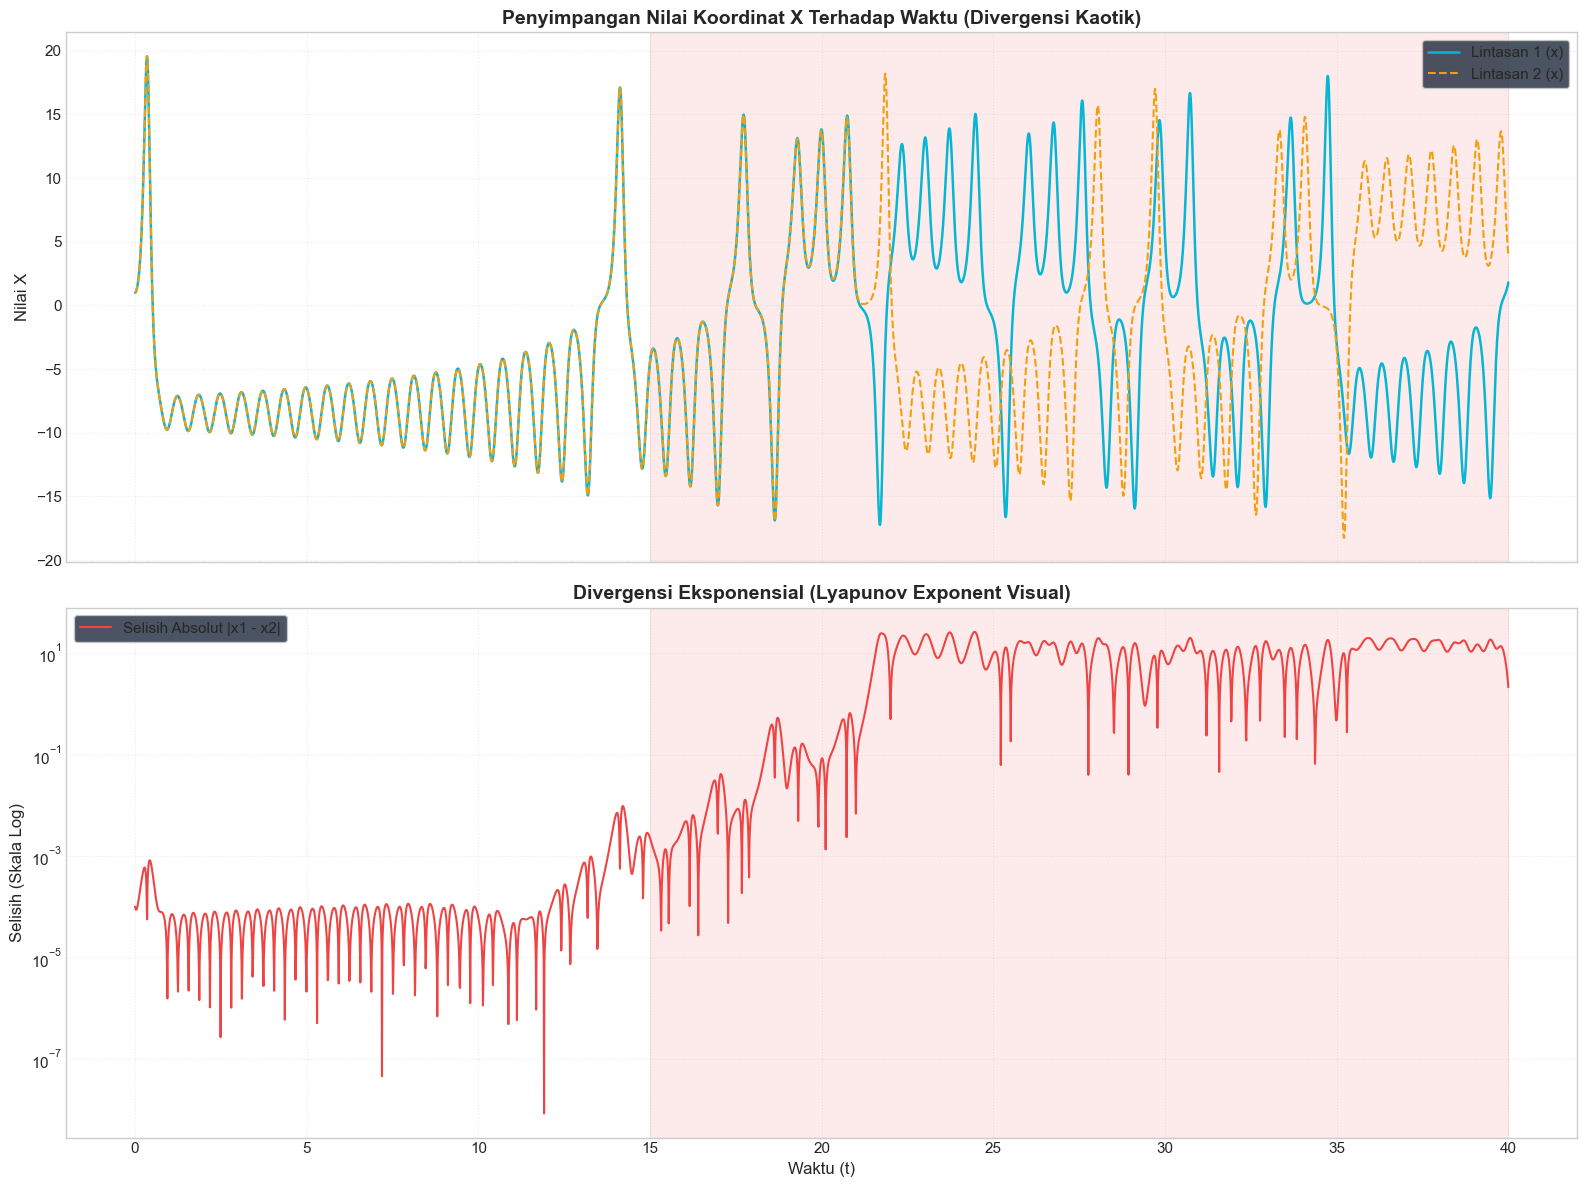

In [35]:
fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

# 1. Plot nilai X terhadap Waktu
axes[0].plot(t_eval, x1, color='#06b6d4', label='Lintasan 1 (x)', linewidth=1.8)
axes[0].plot(t_eval, x2, color='#f59e0b', label='Lintasan 2 (x)', linestyle='--', linewidth=1.5)
axes[0].set_title('Penyimpangan Nilai Koordinat X Terhadap Waktu (Divergensi Kaotik)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Nilai X')
axes[0].legend(loc='upper right', frameon=True, facecolor='#1e293b')
axes[0].grid(True, linestyle=':', alpha=0.4)

# 2. Plot Selisih Absolut antara Lintasan 1 dan Lintasan 2 (Skala Logaritmik)
delta_x = np.abs(x1 - x2)
axes[1].semilogy(t_eval, delta_x, color='#ef4444', linewidth=1.5, label='Selisih Absolut |x1 - x2|')
axes[1].set_title('Divergensi Eksponensial (Lyapunov Exponent Visual)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Waktu (t)')
axes[1].set_ylabel('Selisih (Skala Log)')
axes[1].legend(loc='upper left', frameon=True, facecolor='#1e293b')
axes[1].grid(True, which='both', linestyle=':', alpha=0.4)

# Beri arsiran saat divergensi mulai terlihat secara makroskopis
axes[0].axvspan(15, t_end, color='#ef4444', alpha=0.1, label='Fase Kaotik Divergen')
axes[1].axvspan(15, t_end, color='#ef4444', alpha=0.1)

plt.tight_layout()
plt.savefig('lorenz_divergence_time_series.png', dpi=300)
plt.show()


## 5. Visualisasi 3D Interaktif Menggunakan Plotly

Gunakan kursor mouse Anda untuk memutar (klik kiri & tahan), menggeser (klik kanan & tahan), atau men-zoom (scroll wheel) grafik 3D di bawah ini untuk mengamati pola atraktor Lorenz secara interaktif.

In [37]:
try:
    import plotly.graph_objects as go
    plotly_available = True
except ImportError:
    plotly_available = False

if plotly_available:
    fig = go.Figure()
    
    # Lintasan 1 (Biru Neon)
    fig.add_trace(go.Scatter3d(
        x=x1, y=y1, z=z1,
        mode='lines',
        name='Kondisi Awal 1',
        line=dict(color='#06b6d4', width=2.5)
    ))
    
    # Lintasan 2 (Amber/Oranye Neon)
    fig.add_trace(go.Scatter3d(
        x=x2, y=y2, z=z2,
        mode='lines',
        name='Kondisi Awal 2',
        line=dict(color='#f59e0b', width=2, dash='dash')
    ))
    
    # Desain Layout Plotly Dark Mode
    fig.update_layout(
        title=dict(
            text='Interactive 3D Lorenz Attractor',
            font=dict(size=16, color='white')
        ),
        template='plotly_dark',
        scene=dict(
            xaxis=dict(title='Sumbu X'),
            yaxis=dict(title='Sumbu Y'),
            zaxis=dict(title='Sumbu Z')
        ),
        margin=dict(l=0, r=0, b=0, t=50)
    )
    
    fig.show()


In [1]:
import pandas as pd

data = [
    [1, "temperature", "Termodinamika Permukaan", "ERA5 Reanalysis (2m Temp)", "AWS IoT (Sensor SHT40)", "REPLACED", "Menyesuaikan profil suhu udara makro ke mikroklimat tanah lokal"],
    [2, "humidity", "Kelembapan Udara", "ERA5 Reanalysis", "AWS IoT (Sensor SHT40)", "REPLACED", "Mengganti kelembapan grid regional dengan kelembapan riil permukaan"],
    [3, "dewpoint", "Titik Embun (Moisture)", "ERA5 Reanalysis", "AWS IoT (Magnus Formula)", "REPLACED", "Mengukur kandungan uap air aktual sebelum kondensasi lokal"],
    [4, "pressure", "Tekanan Permukaan", "ERA5 (MSLP / 100)", "AWS IoT (Sensor MS5611)", "REPLACED", "Menangkap fluktuasi tekanan barometrik lokal secara presisi"],
    [5, "rainrate", "Presipitasi Jam Berjalan", "Satelit GSMaP", "AWS IoT (Tipping Bucket)", "REPLACED", "Mengeliminasi bias satelit dengan takaran air hujan fisik di tanah"],
    [6, "era5_u_wind", "Dinamika Angin Zonal", "ERA5 Reanalysis (U 10m)", "ERA5 Reanalysis (U 10m)", "RETAINED", "Mempertahankan vektor adveksi kelembapan arah Barat-Timur"],
    [7, "era5_v_wind", "Dinamika Angin Meridional", "ERA5 Reanalysis (V 10m)", "ERA5 Reanalysis (V 10m)", "RETAINED", "Mempertahankan vektor adveksi kelembapan arah Utara-Selatan"],
    [8, "era5_cloud_cover", "Optik Atmosfer", "ERA5 (Total Cloud Cover)", "ERA5 (Total Cloud Cover)", "RETAINED", "Proksi tutupan awan vertikal yang tidak terukur oleh sensor darat"],
    [9, "era5_cape", "Stabilitas Udara Atas", "ERA5 Reanalysis (CAPE)", "ERA5 Reanalysis (CAPE)", "RETAINED", "Energi potensial pemicu awan konvektif di kolom atmosfer atas"],
    [10, "era5_tcwv", "Kolom Total Uap Air", "ERA5 Reanalysis (TCWV)", "ERA5 Reanalysis (TCWV)", "RETAINED", "Akumulasi massa uap air vertikal dari permukaan hingga stratosfer"],
    [11, "era5_moisture_div", "Konvergensi Massa Udara", "ERA5 Reanalysis", "ERA5 Reanalysis", "RETAINED", "Indikator pemusatan massa udara basah pemicu hujan konvektif"],
    [12, "era5_direct_rad", "Radiasi Surya", "ERA5 (Direct Solar Rad)", "ERA5 (Direct Solar Rad)", "RETAINED", "Pemicu utama siklus pemanasan termal diurnal permukaan"],
    [13, "era5_sunshine", "Durasi Penyinaran", "ERA5 (Sunshine Proxy)", "ERA5 (Sunshine Proxy)", "RETAINED", "Karakteristik durasi pemanasan atmosfer lokal harian"],
    ["Target", "target_amount & occ", "Target Prediksi (t+1)", "Satelit GSMaP", "AWS IoT (Tipping Bucket)", "REPLACED", "Target verifikasi prediksi hujan 1 jam ke depan di titik pengamatan"]
]

columns = ["No", "Nama Variabel", "Kategori Parameter", "Sumber Data (Pre-Training)", "Sumber Data (Fine-Tuning)", "Status di Fine-Tuning", "Justifikasi Fisis & Metodologis"]
df = pd.DataFrame(data, columns=columns)
df.to_excel("Pemetaan_Variabel_Sidang.xlsx", index=False)
print("File Pemetaan_Variabel_Sidang.xlsx berhasil dibuat!")

File Pemetaan_Variabel_Sidang.xlsx berhasil dibuat!
